<a href="https://colab.research.google.com/github/iamnaymur/ml_meta_learning/blob/main/week03_model_fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("hello world")

hello world


# ML models fundamentals

In [ ]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder


# Load Heart dataset
uploaded = '/content/drive/MyDrive/Machine learning/heart.csv'

df_heart = pd.read_csv(uploaded)

print("First 10 rows of Heart dataset:")
display(df_heart.head(10))

print("\nColumn data types:")
display(df_heart.dtypes)

First 10 rows of Heart dataset:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0



Column data types:


,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


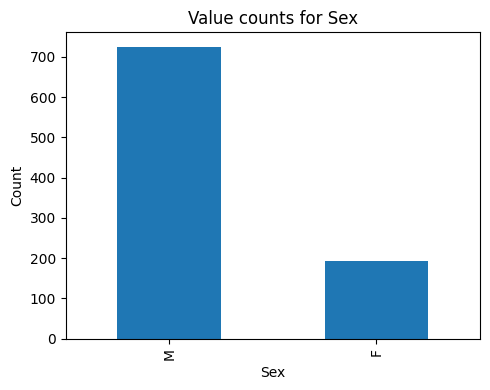

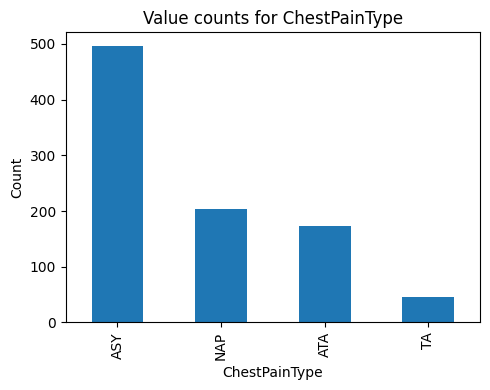

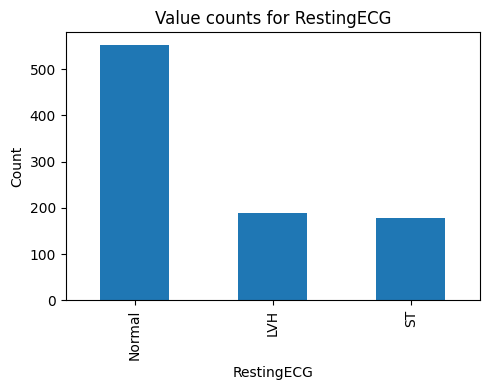

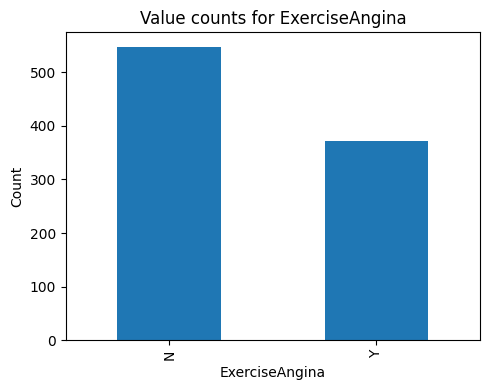

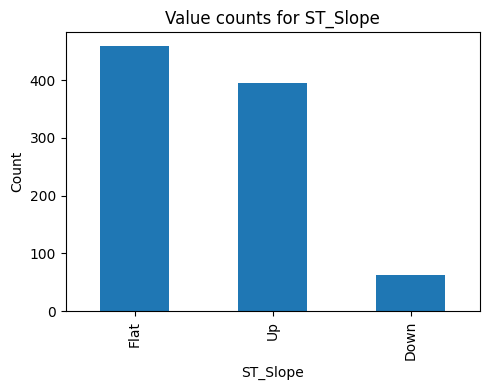

In [ ]:
#Categorical Feature Exploration
categorical_cols = ["Sex", "ChestPainType", "RestingECG",
                    "ExerciseAngina", "ST_Slope"]
for c in categorical_cols:
  plt.figure(figsize=(5,4))
  df_heart[c].value_counts().plot(kind="bar")
  plt.title(f"Value counts for {c}")
  plt.ylabel("Count")
  plt.tight_layout()
  plt.show()

In [ ]:
# Label Encoding for binary categorical columns -> Sex and ExerciseAngina
le = LabelEncoder()
df_heart["Sex"] = le.fit_transform(df_heart["Sex"])
df_heart["ExerciseAngina"] = le.fit_transform(df_heart["ExerciseAngina"])

In [ ]:
df_heart.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,0,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,0,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,1,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,0,0.0,Up,0
5,39,1,NAP,120,339,0,Normal,170,0,0.0,Up,0
6,45,0,ATA,130,237,0,Normal,170,0,0.0,Up,0
7,54,1,ATA,110,208,0,Normal,142,0,0.0,Up,0
8,37,1,ASY,140,207,0,Normal,130,1,1.5,Flat,1
9,48,0,ATA,120,284,0,Normal,120,0,0.0,Up,0


In [ ]:
# OneHot Encoding for nominal categorical columns
cat_cols = ["ChestPainType", "RestingECG", "ST_Slope"]

df_heart_encoded = pd.get_dummies(
    df_heart,
    columns = cat_cols,
    dtype=int
)

In [ ]:
df_heart_encoded.head(10)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,0,1,0,0,0,1,0,0,0,1
1,49,0,160,180,0,156,0,1.0,1,0,0,1,0,0,1,0,0,1,0
2,37,1,130,283,0,98,0,0.0,0,0,1,0,0,0,0,1,0,0,1
3,48,0,138,214,0,108,1,1.5,1,1,0,0,0,0,1,0,0,1,0
4,54,1,150,195,0,122,0,0.0,0,0,0,1,0,0,1,0,0,0,1
5,39,1,120,339,0,170,0,0.0,0,0,0,1,0,0,1,0,0,0,1
6,45,0,130,237,0,170,0,0.0,0,0,1,0,0,0,1,0,0,0,1
7,54,1,110,208,0,142,0,0.0,0,0,1,0,0,0,1,0,0,0,1
8,37,1,140,207,0,130,1,1.5,1,1,0,0,0,0,1,0,0,1,0
9,48,0,120,284,0,120,0,0.0,0,0,1,0,0,0,1,0,0,0,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Assume df_heart_encoded is our working dataframe with target 'HeartDisease'
target_col = "HeartDisease"

X = df_heart_encoded.drop(columns=[target_col])
y = df_heart_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .25, random_state=42)

# Standard Scaling
scaler_sd = StandardScaler()
X_train_std = scaler_sd.fit_transform(X_train)#mean and SD will be calcualted from X_train
X_test_std = scaler_sd.transform(X_test)

# MinMax Scaling
scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm = scaler_mm.transform(X_test)



print("\n--- Displaying Standard Scaled Data ---")
# Convert scaled arrays back to DataFrame for better visualization with column names
X_train_std_df = pd.DataFrame(X_train_std, columns = X_train.columns, index = X_train.index)
X_test_std_df = pd.DataFrame(X_test_std, columns = X_test.columns, index = X_test.index)
print("\nFirst 5 rows of X_train & X_test (Standard Scaled):")
display(X_train_std_df.head())
display(X_test_std_df.head())


print("\n--- Displaying Standard Scaled Data ---")
# Convert scaled arrays back to DataFrame for better visualization with column names
X_train_mm_df = pd.DataFrame(X_train_mm, columns = X_train.columns, index = X_train.index)
X_test_mm_df = pd.DataFrame(X_test_mm, columns = X_test.columns, index = X_test.index)

print("\nFirst 5 rows of X_train (Minmax Scaled):")
display(X_train_mm_df.head())
display(X_test_mm_df.head())


--- Displaying Standard Scaled Data ---

First 5 rows of X_train & X_test (Standard Scaled):


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
155,0.239292,0.537019,1.183802,1.307314,1.877849,0.551672,1.182037,1.900458,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064
362,0.239292,0.537019,1.183802,-1.878000,-0.532524,-1.486343,-0.845997,-0.834739,-1.104244,-0.480384,1.885813,-0.213524,-0.505445,-1.225487,2.023931,-0.254981,0.962897,-0.851064
869,0.558968,0.537019,0.913811,0.096522,1.877849,0.831400,-0.845997,0.624033,-1.104244,-0.480384,1.885813,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
101,-0.293501,0.537019,-0.166155,-0.210833,-0.532524,-1.446382,-0.845997,-0.834739,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
199,0.345851,-1.862131,-0.166155,0.990645,-0.532524,-1.526304,-0.845997,0.076994,-1.104244,-0.480384,-0.530275,4.683304,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
668,0.985202,-1.862131,0.373828,-0.061812,-0.532524,1.710544,-0.845997,-0.834739,-1.104244,2.081666,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
30,-0.080384,0.537019,0.643819,2.946539,-0.532524,-0.247550,-0.845997,-0.834739,-1.104244,-0.480384,1.885813,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064
377,1.198319,0.537019,1.453793,-1.878000,1.877849,-0.567238,-0.845997,0.259340,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,-1.225487,2.023931,-0.254981,0.962897,-0.851064
535,0.239292,0.537019,-0.166155,-1.878000,-0.532524,-0.567238,1.182037,0.076994,0.905597,-0.480384,-0.530275,-0.213524,1.978455,-1.225487,-0.494088,-0.254981,0.962897,-0.851064
807,0.026175,0.537019,-1.354116,0.999959,-0.532524,0.791439,-0.845997,-0.834739,-1.104244,2.081666,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999



--- Displaying Standard Scaled Data ---

First 5 rows of X_train (Minmax Scaled):


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
155,0.562500,1.0,0.775,0.567164,1.0,0.674419,1.0,0.636364,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
362,0.562500,1.0,0.775,0.000000,0.0,0.279070,0.0,0.295455,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
869,0.625000,1.0,0.750,0.351575,1.0,0.728682,0.0,0.477273,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
101,0.458333,1.0,0.650,0.296849,0.0,0.286822,0.0,0.295455,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
199,0.583333,0.0,0.650,0.510779,0.0,0.271318,0.0,0.409091,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
668,0.708333,0.0,0.700,0.323383,0.0,0.899225,0.0,0.295455,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
30,0.500000,1.0,0.725,0.859038,0.0,0.519380,0.0,0.295455,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
377,0.750000,1.0,0.800,0.000000,1.0,0.457364,0.0,0.431818,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
535,0.562500,1.0,0.650,0.000000,0.0,0.457364,1.0,0.409091,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
807,0.520833,1.0,0.540,0.512438,0.0,0.720930,0.0,0.295455,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


## Data Preprocessing and Feature Engineering (Part 2)
> previous part is from week 2, just copy pasted here because i need it for the codes below



> The first part is in week02, module 07


> Week 3 started from here.



### Handling Outliers

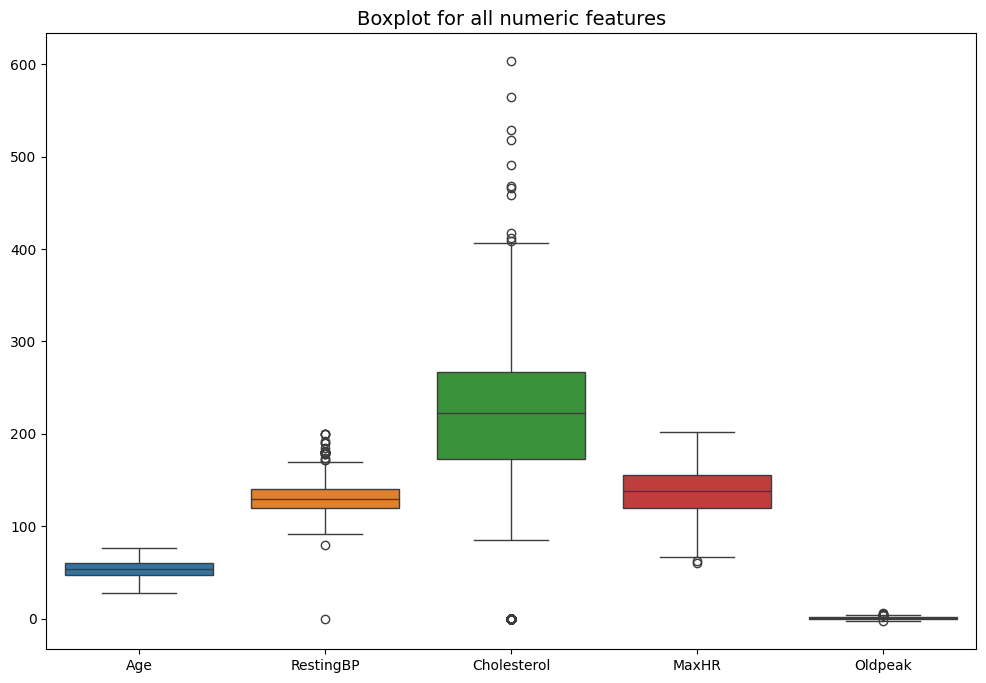

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize some numeric columns
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

plt.figure(figsize=(12, 8))
# here the boxplot from sns
sns.boxplot(data = df_heart_encoded[numeric_cols])
plt.title("Boxplot for all numeric features", fontsize = 14)
plt.show()

In [ ]:
# use iqr method on cholesterol as an example
col = "Cholesterol"
Q1 = df_heart_encoded[col].quantile(0.25)
Q3 = df_heart_encoded[col].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 *IQR
upper = Q3 + 1.5 * IQR

# This code below means ,select all rows where the Cholesterol value is either below the lower limit OR above the upper limit...
outliers = df_heart_encoded[(df_heart_encoded[col] < lower) | (df_heart_encoded[col] > upper)]
print(f"Number of outliers in  {col}" , len(outliers))

Number of outliers in  Cholesterol 183


In [ ]:
"""
There are three things we can do to handle outliers
1. Remove outliers
2. Cal outliers (winsorization-like approach)
3. Log tranform the column (for skewed distributions)
"""

# 1. Remove outliers -> jokhon dataset onek boro hobe and the count of outliers will be so minimum compared to the total data
df_no_outliers = df_heart_encoded[(df_heart_encoded[col] >= lower) & (df_heart_encoded[col] <= upper)]


# print(len(df_no_outliers))

"""
# 2. Cap outliers
How capping works -> [180, 190, 195, 200, 205, 2100]
suppose here the q1 is 190
q2 = 205
Iqr = 15
Upper 227, lower 167

So eikhane 2100 227 diya replace hoiya jabe
and 167 er niche kichu thakle oida 167 diya replace hoiya jaito
"""

df_capped = df_heart_encoded.copy()
df_capped[col] = df_capped[col].clip(lower, upper)
# print(df_capped)

"""
3. Long transform the column (for skewed distributions)
+1 is used there, what if there is a 0, and then it will be undefined.

so what this log does [90, 100, 110, 300] -> 300 is  a outlier right?

but ....
log[90 + 1] -> 4.51
log[100 + 1] -> 4.62
log[110 + 1] -> 4.71
log[300 + 1] -> 5.02

even if the 300 is a large number, it came down to 5 and close to the log of the other values
"""

df_log = df_heart_encoded.copy()
df_log[col + "_log"] = np.log(df_log[col] + 1)

print(df_log) #a new column cholesterol log will be added

     Age  Sex  RestingBP  Cholesterol  FastingBS  MaxHR  ExerciseAngina  \
0     40    1        140          289          0    172               0   
1     49    0        160          180          0    156               0   
2     37    1        130          283          0     98               0   
3     48    0        138          214          0    108               1   
4     54    1        150          195          0    122               0   
..   ...  ...        ...          ...        ...    ...             ...   
913   45    1        110          264          0    132               0   
914   68    1        144          193          1    141               0   
915   57    1        130          131          0    115               1   
916   57    0        130          236          0    174               0   
917   38    1        138          175          0    173               0   

     Oldpeak  HeartDisease  ChestPainType_ASY  ChestPainType_ATA  \
0        0.0             0     

### Feature Transformation and domain-drive features part 01

In [ ]:
"""
1. polynomial feature
2. binning
3. domain driven features
"""

# Polynomial featurs using Age and MaxHR
from sklearn.preprocessing import PolynomialFeatures


poly_cols = ["Age", "MaxHR"]
# degree 2 here is usual
# bias to ignore 1s useless col
poly = PolynomialFeatures(degree = 2, include_bias = False)
poly_features = poly.fit_transform(df_heart_encoded[poly_cols])
poly_features_name = poly.get_feature_names_out(poly_cols)

print(poly_features_name)

print(poly_features.shape)

['Age' 'MaxHR' 'Age^2' 'Age MaxHR' 'MaxHR^2']
(918, 5)


### Feature Transformation and domain-drive features part 01

In [ ]:
# Binning age into categoris (young, middle, old)
df_heart_encoded["Age_bin"] = pd.cut(
    df_heart_encoded["Age"],
    bins = [0, 30, 50, 100],
    labels = ["young", "middle", "old"]
)

print(df_heart_encoded[["Age", "Age_bin"]].head(10))

   Age Age_bin
0   40  middle
1   49  middle
2   37  middle
3   48  middle
4   54     old
5   39  middle
6   45  middle
7   54     old
8   37  middle
9   48  middle


In [ ]:
# domain driven risk categories for restingBp and oldpeak
# age 2 ta featur er binning korte hobe
"""
As we are again binning here, then you might be thinking whats the difference between binning and domain driven feature engineering here?
-> Domain-Driven Feature Engineering means creating new features using real-world knowledge of the problem (not just mathematical transformations). You use expert/domain knowledge to create more meaningful features.
"""

def bp_risk(bp):
  if bp < 120:
    return "Normal"
  elif bp< 140:
    return "Elevated"
  else:
      return "High"

def oldpeak_risk(op):
  if op == 0:
    return "No Stress"
  elif op < 2:
    return "Moderate Stress"
  else:
      return "High Stress"

df_heart_encoded["BP_Risk"] = df_heart_encoded["RestingBP"].apply(bp_risk)

df_heart_encoded["Oldpeak_Risk"] = df_heart_encoded["Oldpeak"].apply(oldpeak_risk)

df_heart_encoded[["RestingBP", "BP_Risk", "Oldpeak", "Oldpeak_Risk"]]


,RestingBP,BP_Risk,Oldpeak,Oldpeak_Risk
0,140,High,0.0,No Stress
1,160,High,1.0,Moderate Stress
2,130,Elevated,0.0,No Stress
3,138,Elevated,1.5,Moderate Stress
4,150,High,0.0,No Stress
...,...,...,...,...
913,110,Normal,1.2,Moderate Stress
914,144,High,3.4,High Stress
915,130,Elevated,1.2,Moderate Stress
916,130,Elevated,0.0,No Stress


Putting it all together in a preprocessing pipeline

In [ ]:
"""
A pipeline automatically chains preprocessing + model training into one object
YOu just have to do like

--------------------------
clf.fit(X_train, Y_train)
clf.predict(X_test)
--------------------------

It handles scaling, encoding, and prection all together..
"""

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define numeric and categorical columns for the pipeline
num_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
cat_features = ["Sex", "ExerciseAngina", "ChestPainType", "RestingECG", "ST_Slope"]

# Numeric pipeline
num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ("ohe", OneHotEncoder(drop = "first"))
])

# Combine both
preprocess = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

# full pipeline with a simple model
clf = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter = 1000))
])



In [ ]:
from sklearn.metrics import accuracy_score

# train-test split using original df_heart (not already encoded one , cause the pipeline will encode it again)
X= df_heart.drop(columns = [target_col])
Y = df_heart[target_col]

X_train_pipe, X_test_pipe, Y_train_pipe, Y_test_pipe = train_test_split(X, Y, test_size= 0.25, random_state = 42)

# fir the pipeline
clf.fit(X_train_pipe, Y_train_pipe)

# predict and evaluate

Y_pred_pipe = clf.predict(X_test_pipe)
print(accuracy_score(Y_test_pipe, Y_pred_pipe))

# 84% accuracy on the heart_disease dataset

0.8434782608695652


##Module : 10 Linear Regression and Logistic Regression

### Hands  on of Linear Regression an Best fitted line

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [ ]:
#createing a simple dataset
hours = np.array([2, 4, 6, 8, 10]).reshape(-1, 1)
marks= np.array([55, 60, 70, 80, 88])

hours, marks

(array([[ 2],
        [ 4],
        [ 6],
        [ 8],
        [10]]),
 array([55, 60, 70, 80, 88]))

In [ ]:
# train a linear regression model

model = LinearRegression()
model.fit(hours, marks)

LinearRegression()

In [ ]:
# view the learned parameters
# y = mx + c
print("m: ", model.coef_[0]) #this is the sloope, we get 4.3
print("c :", model.intercept_) #we get for intercept, 44.8

# marks = 4.3 * hours + 44.8

m:  4.3
c : 44.8


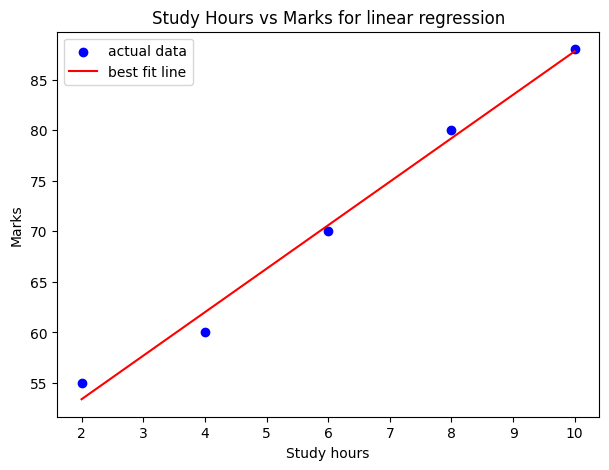

In [ ]:
# visualize the best fit line
plt.scatter(hours, marks, color= 'blue', label = "actual data")
prediction = model.predict(hours)
plt.plot(hours, prediction, color = "red", label = "best fit line")
plt.xlabel("Study hours")
plt.ylabel("Marks")

plt.title("Study Hours vs Marks for linear regression")
plt.legend()
plt.show()

In [ ]:
# predict marks for  a student now
new_hours = np.array([[7]])
prediction = model.predict(new_hours)
print("Predicted marks :", prediction[0])

Predicted marks : 74.89999999999999


### Cost function and Gradient descent

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error



hours = np.array([2, 4, 6, 8, 10]).reshape(-1, 1)
marks= np.array([55, 60, 70, 80, 88])

# hours, marks

# For a linear regression model
lin_reg_model = LinearRegression()
lin_reg_model.fit(hours, marks)


print("m :", lin_reg_model.coef_[0])
print("c :", lin_reg_model.intercept_)

# Compute the cost (Mean square error) using  a library function
prediction_marks = lin_reg_model.predict(hours)
mse_lin = mean_squared_error(marks,prediction_marks)
print("MSE for linear regression :", mse_lin) #the res here is 1.52, so we can say that the distance between the prediction line and actual values are so small



m : 4.3
c : 44.8
MSE for linear regression : 1.5200000000000033


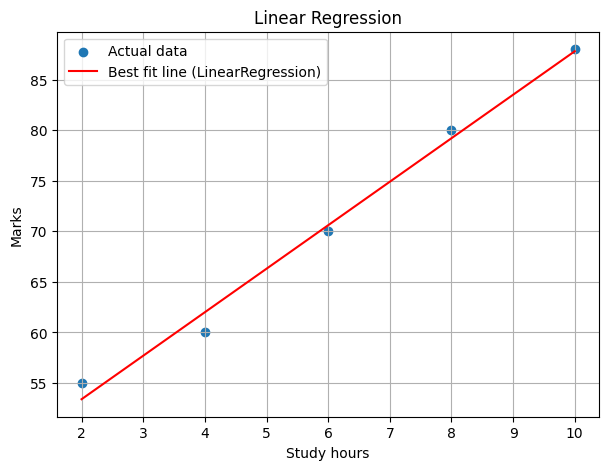

In [ ]:
plt.scatter(hours, marks, label = "Actual data")
plt.plot(hours, prediction_marks, label = "Best fit line (LinearRegression)", color = "red")
plt.xlabel("Study hours")
plt.ylabel("Marks")
plt.title("Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

m : 5.698065492806587
c 34.475265427340794
Mse of sgdregressor 20.906115830567398


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


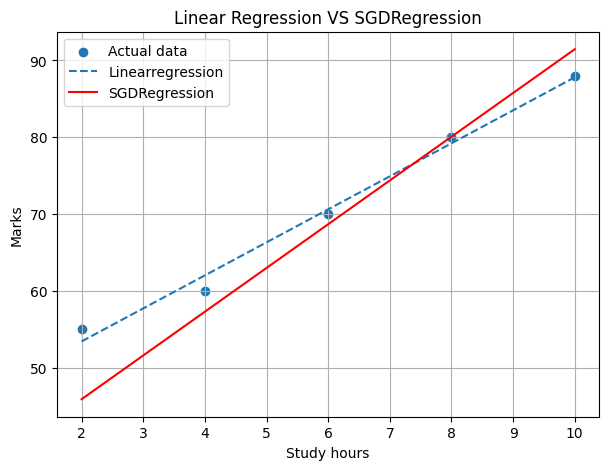

In [ ]:
# Now using a gradient-descent-based model - SGDRegressor

"""
SGDRegressor is a regression model that used Stochastic Gradient Descent (SGD) internally

It has the same goal, but using gradient steps instred of a direct formula, using gradient descent helps to find the best fit line by increasing or decreasing the values for both C and M
"""

sgd_reg_model = SGDRegressor(
    max_iter = 1000,
    learning_rate = "invscaling",
    eta0 = 0.01,
    random_state = 42
)

sgd_reg_model.fit(hours, marks)
print("m :", sgd_reg_model.coef_[0])
print("c" , sgd_reg_model.intercept_[0])


pred_sgd = sgd_reg_model.predict(hours)
mse_sgd = mean_squared_error(marks, pred_sgd)

print("Mse of sgdregressor",mse_sgd)

# compare both visually
plt.scatter(hours, marks, label = "Actual data")
plt.plot(hours, prediction_marks, label= "Linearregression", linestyle = '--')
plt.plot(hours, pred_sgd, label = "SGDRegression", color = "red")
plt.xlabel("Study hours")
plt.ylabel("Marks")
plt.title("Linear Regression VS SGDRegression")
plt.legend()
plt.grid(True)
plt.show()

### Regression Evaluation Metrics (R^2, MAE, RMSE)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

hours = np.array([2, 4, 6, 8, 10]).reshape(-1, 1)
marks= np.array([55, 60, 70, 80, 88])

model = LinearRegression()
model.fit(hours, marks)
pred = model.predict(hours)
# print(pred)

In [ ]:
# Computer metrics
mae = mean_absolute_error(marks, pred)
mse = mean_squared_error(marks, pred) #not individual datapoints error
rmse = np.sqrt(mse) #indidual datapoints error
r2 = r2_score(marks, pred)


print(r2)
print(rmse)
print(mae)

0.9898286937901499
1.2328828005937966
1.040000000000002


## Module 11 :Decision Trees

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
)

# make plots a bit larger by default
plt.rcParams['figure.figsize'] = (7, 5)

In [ ]:
# create a small synthetic dataset
data = {
    'Weather': ['Sunny', 'Rainy', 'Sunny', 'Sunny', 'Rainy', 'Rainy', 'Sunny', 'Rainy'],
    'Windy' : [0, 1, 0, 1, 0, 1 , 0,  1],
    'Play' : [1, 0, 1, 1 , 0, 0, 1, 0]
}

df_synthetic = pd.DataFrame(data)
# df_synthetic

# Encoding the categorical feature and prepare X, Y
df_synthetic['Weather_num'] = df_synthetic['Weather'].map({'Sunny' : 1, 'Rainy' : 0})

# df_synthetic


X_synthetic = df_synthetic[['Weather_num', 'Windy']]
Y_synthetic = df_synthetic['Play']

# X_synthetic
# Y_synthetic



In [ ]:
# train a simple decision tree
tree_synthetic = DecisionTreeClassifier(max_depth=3, random_state = 42)
tree_synthetic.fit(X_synthetic, Y_synthetic)

tree_synthetic

DecisionTreeClassifier(max_depth=3, random_state=42)

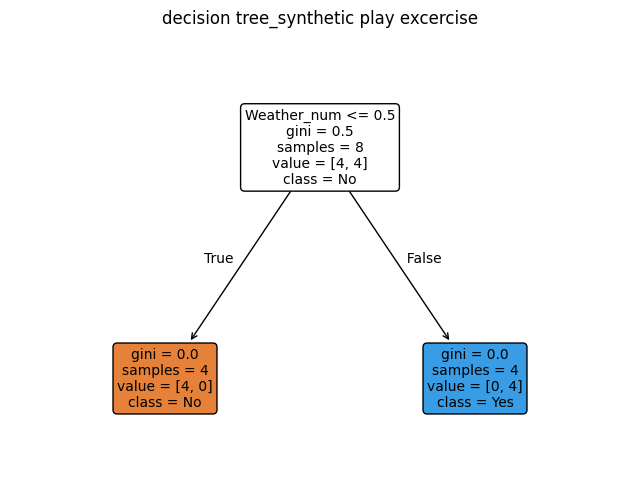

In [ ]:
# Visualize the tree
plt.figure(figsize =(8, 6))
plot_tree(
    tree_synthetic,
    feature_names = ['Weather_num', 'Windy'],
    class_names = ['No' , 'Yes'],
    filled = True,
    rounded = True,
    fontsize = 10
)

plt.title("decision tree_synthetic play excercise")
plt.show()

In [ ]:
# Example: Predict for sunny (1) and not windy (0)
example_1 = pd.DataFrame([[1, 0]], columns = ['Weather_num', 'Windy'])
pred_1 = tree_synthetic.predict(example_1)
print("Prediction for example 1 :", pred_1)

Prediction for example 1 : [1]


### OverFitting and Pruning

In [ ]:
from sklearn.datasets import make_classification
X_big, Y_big = make_classification(
    n_samples = 400, #total data points
    n_features = 10, #total feature number
    n_informative = 3, #total relevant features
    n_redundant = 0, #no strong correlation among the features
    n_classes = 2, #target variable/ feature class number
    random_state = 42
)

X_train_big, X_test_big, Y_train_big, Y_test_big = train_test_split(X_big, Y_big, test_size = 0.3, random_state = 42)

In [ ]:
# Train a deep tree vs a pruned tree
deep_tree = DecisionTreeClassifier(random_state = 42)
deep_tree.fit(X_train_big, Y_train_big)

# the only diff here is max_depth
pruned_tree = DecisionTreeClassifier(max_depth = 3, random_state = 42)
pruned_tree.fit(X_train_big, Y_train_big)

# We do this to see how well the tree performs on data it has already seen.
Y_train_pred_deep = deep_tree.predict(X_train_big)
# Now the tree predicts labels for test data, which it hasn't seen during training.
Y_test_pred_deep = deep_tree.predict(X_test_big)



Y_train_pred_pruned = pruned_tree.predict(X_train_big)
Y_test_pred_pruned = pruned_tree.predict(X_test_big)



print('Deep tree - train accuracy:', round(accuracy_score(Y_train_big, Y_train_pred_deep), 2))
print('Deep tree - test accuracy:', round(accuracy_score(Y_test_big, Y_test_pred_deep), 2))

print('Pruned tree - train accuracy:', round(accuracy_score(Y_train_big, Y_train_pred_pruned), 2))
print('Pruned tree - test accuracy:', round(accuracy_score(Y_test_big, Y_test_pred_pruned), 2))


Deep tree - train accuracy: 1.0
Deep tree - test accuracy: 0.83
Pruned tree - train accuracy: 0.91
Pruned tree - test accuracy: 0.88


### Visual comparison between deep vs pruned tree

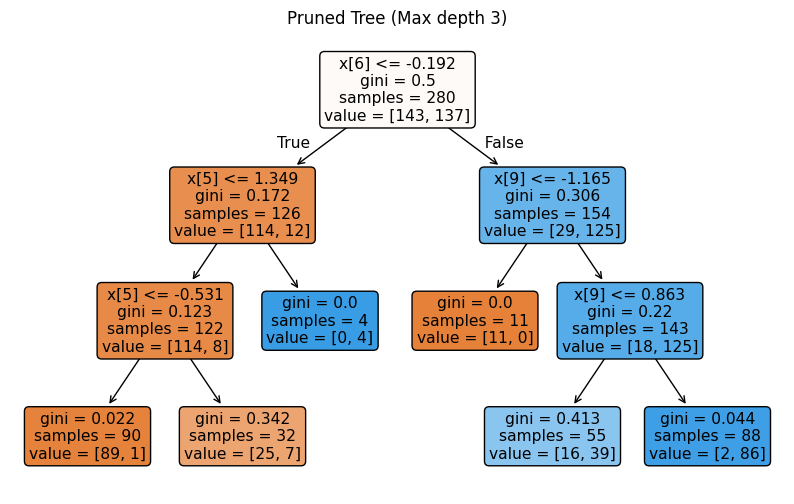

In [ ]:
# plt.figure(figsize = (10, 6))
# plot_tree(deep_tree, filled = True, rounded = True, max_depth= 3)
# plt.title("Deep Tree (top 3 levels)")
# plt.show()



plt.figure(figsize = (10, 6))
plot_tree(pruned_tree, filled = True, rounded = True, max_depth= 3)
plt.title("Pruned Tree (Max depth 3)")
plt.show()

### Evaluating a decision tree(accuracy, precision, recall,f1, confusion_matrix)

In [ ]:
# code for creating fake / synthetic dataset
np.random.seed(42)
n_samples = 300

age = np.random.randint(30, 80, size=n_samples)
chol = np.random.randint(150, 300, size=n_samples)
thalach = np.random.randint(90, 200, size=n_samples)

# We create a simple rule-based probability for disease just for realism
risk_score = 0.03 * (age - 40) + 0.02 * (chol - 200) - 0.02 * (thalach - 140)
prob = 1 / (1 + np.exp(-0.05 * risk_score))

target = (prob > np.median(prob)).astype(int)

df_heart = pd.DataFrame({
    'age': age,
    'chol': chol,
    'thalach': thalach,
    'target': target
})

df_heart.head(10)

,age,chol,thalach,target
0,68,253,128,1
1,58,233,90,1
2,44,261,92,1
3,72,248,166,1
4,37,242,181,0
5,50,295,151,1
6,68,277,152,1
7,48,259,114,1
8,52,231,145,0
9,40,203,122,0


In [ ]:
# traun test split and model training
X_heart = df_heart[['age', 'chol', 'thalach']]
Y_heart = df_heart['target']


X_train_heart, X_test_heart, Y_train_heart, Y_test_heart = train_test_split(X_heart, Y_heart, test_size = 0.2, random_state = 42)


tree_heart = DecisionTreeClassifier(max_depth = 4, random_state = 42)
tree_heart.fit(X_train_heart, Y_train_heart)

tree_heart


DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
# confusion matrix
Y_pred_heart  = tree_heart.predict(X_test_heart)

cm = confusion_matrix(Y_test_heart, Y_pred_heart)
print(cm)

[[23  3]
 [ 6 28]]


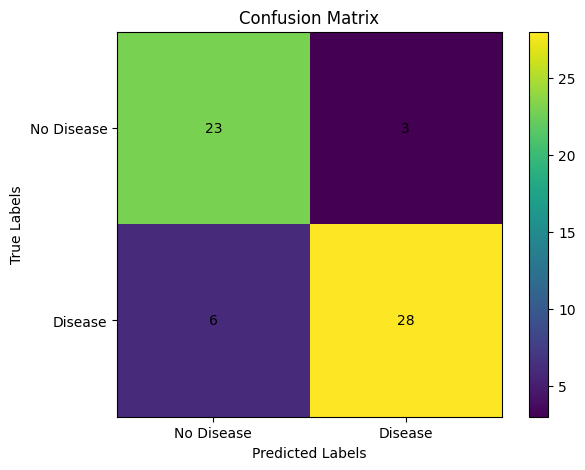

In [ ]:
# Plot of confusion matrix
fig, ax = plt.subplots()

im = ax.imshow(cm, interpolation='nearest')

ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Labels")
ax.set_ylabel("True Labels")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(['No Disease', 'Disease'])
ax.set_yticklabels(['No Disease', 'Disease'])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar(im)
plt.show()

In [ ]:
# accuracy, precision, recall and f1

ac_score = accuracy_score(Y_test_heart, Y_pred_heart)
pre_score = precision_score(Y_test_heart, Y_pred_heart)
rec_score = recall_score(Y_test_heart, Y_pred_heart)
f1_score = f1_score(Y_test_heart, Y_pred_heart)

print("Accuracy:", round(ac_score, 2))
# precison 90% → Of the patients the model predicted as having disease, 90% actually had disease.
print("Precision:", round(pre_score, 2))
# Recall = 82% → Of the patients who actually had disease, the model correctly identified 82%.
print("Recall:", round(rec_score, 2))
print("F1 Score:", round(f1_score, 2))

Accuracy: 0.85
Precision: 0.9
Recall: 0.82
F1 Score: 0.86


### Roc curve and Auc

In [ ]:
# predicted probabilities
# for an ROC curve, we don't only look at the model's final decision (0 or 1). We look at how confident the model is about each prediction


Y_pred_proba = tree_heart.predict_proba(X_test_heart)[:, 1]
Y_pred_proba[:10]

array([0.875     , 0.        , 0.04761905, 0.        , 0.875     ,
       1.        , 1.        , 1.        , 1.        , 0.        ])

In [ ]:
fpr, tpr, thresholds = roc_curve(Y_test_heart, Y_pred_proba)
roc_auc = auc(fpr, tpr)
print('Auc :', round(roc_auc, 3))



Auc : 0.925


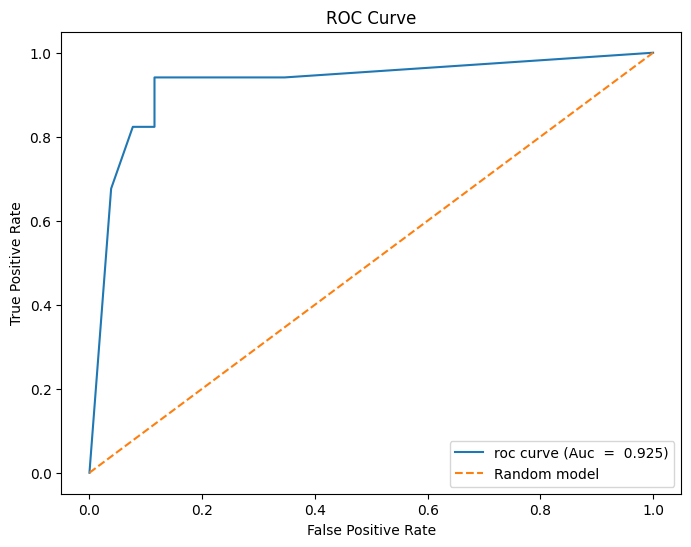

In [ ]:
# plot
plt.figure(figsize = (8, 6))
plt.plot(fpr, tpr, label =f'roc curve (Auc  = {roc_auc : .3f})')
plt.plot([0,1], [0, 1], linestyle = '--', label = 'Random model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()